# **Import Libraries**


In [1]:

import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import cv2

2026-04-29 20:15:26.703074: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777493726.953653      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777493727.023648      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


#  **Load Dataset**


In [2]:


DATASET_PATH = "/kaggle/input/litsdataset2"

images_path = os.path.join(DATASET_PATH, "images")
masks_path  = os.path.join(DATASET_PATH, "masks")

images = []
masks  = []

for img_name in tqdm(os.listdir(images_path)[:500]):  # limit for demo
    img = cv2.imread(os.path.join(images_path, img_name), cv2.IMREAD_GRAYSCALE)
    mask = cv2.imread(os.path.join(masks_path, img_name), cv2.IMREAD_GRAYSCALE)

    img = cv2.resize(img, (128, 128))
    mask = cv2.resize(mask, (128, 128))

    images.append(img)
    masks.append(mask)

images = np.array(images)/255.0
masks  = np.array(masks)/255.0
masks  = np.expand_dims(masks, axis=-1)
images = np.expand_dims(images, axis=-1)

print("Images:", images.shape)
print("Masks:", masks.shape)

100%|██████████| 500/500 [00:11<00:00, 44.26it/s]

Images: (500, 128, 128, 1)
Masks: (500, 128, 128, 1)


#  **Split Data**


In [3]:

X_train, X_val, y_train, y_val = train_test_split(
    images, masks, test_size=0.2, random_state=42
)

print("Train:", X_train.shape, y_train.shape)
print("Val:", X_val.shape, y_val.shape)

Train: (400, 128, 128, 1) (400, 128, 128, 1)
Val: (100, 128, 128, 1) (100, 128, 128, 1)


#  **Data Augmentation**


In [4]:

datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

# **Build U-Net Model**


In [5]:

def unet_model(input_size=(128, 128, 1)):
    inputs = layers.Input(input_size)

    # Encoder
    c1 = layers.Conv2D(16, (3,3), activation="relu", padding="same")(inputs)
    c1 = layers.Dropout(0.1)(c1)
    c1 = layers.Conv2D(16, (3,3), activation="relu", padding="same")(c1)
    p1 = layers.MaxPooling2D((2,2))(c1)

    c2 = layers.Conv2D(32, (3,3), activation="relu", padding="same")(p1)
    c2 = layers.Dropout(0.1)(c2)
    c2 = layers.Conv2D(32, (3,3), activation="relu", padding="same")(c2)
    p2 = layers.MaxPooling2D((2,2))(c2)

    c3 = layers.Conv2D(64, (3,3), activation="relu", padding="same")(p2)
    c3 = layers.Dropout(0.2)(c3)
    c3 = layers.Conv2D(64, (3,3), activation="relu", padding="same")(c3)
    p3 = layers.MaxPooling2D((2,2))(c3)

    # Bottleneck
    c4 = layers.Conv2D(128, (3,3), activation="relu", padding="same")(p3)
    c4 = layers.Dropout(0.3)(c4)
    c4 = layers.Conv2D(128, (3,3), activation="relu", padding="same")(c4)

    # Decoder
    u5 = layers.Conv2DTranspose(64, (2,2), strides=(2,2), padding="same")(c4)
    u5 = layers.concatenate([u5, c3])
    c5 = layers.Conv2D(64, (3,3), activation="relu", padding="same")(u5)
    c5 = layers.Conv2D(64, (3,3), activation="relu", padding="same")(c5)

    u6 = layers.Conv2DTranspose(32, (2,2), strides=(2,2), padding="same")(c5)
    u6 = layers.concatenate([u6, c2])
    c6 = layers.Conv2D(32, (3,3), activation="relu", padding="same")(u6)
    c6 = layers.Conv2D(32, (3,3), activation="relu", padding="same")(c6)

    u7 = layers.Conv2DTranspose(16, (2,2), strides=(2,2), padding="same")(c6)
    u7 = layers.concatenate([u7, c1])
    c7 = layers.Conv2D(16, (3,3), activation="relu", padding="same")(u7)
    c7 = layers.Conv2D(16, (3,3), activation="relu", padding="same")(c7)

    outputs = layers.Conv2D(1, (1,1), activation="sigmoid")(c7)

    model = models.Model(inputs=inputs, outputs=outputs)
    return model

model = unet_model()
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model.summary()


I0000 00:00:1777493756.833674      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        160 │ input_layer[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128, 128,  │          0 │ conv2d[0][0]      │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │      2,320 │ dropout[0][0]     │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │      4,640 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64, 64,    │          0 │ conv2d_2[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │      9,248 │ dropout_1[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │     18,496 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 32, 32,    │          0 │ conv2d_4[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │     36,928 │ dropout_2[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 16, 16,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 16, 16,    │     73,856 │ max_pooling2d_2[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 16, 16,    │          0 │ conv2d_6[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 16, 16,    │    147,584 │ dropout_3[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 32, 32,    │     32,832 │ conv2d_7[0][0]  

 Total params: 481,745 (1.84 MB)

 Trainable params: 481,745 (1.84 MB)

 Non-trainable params: 0 (0.00 B)

#  **Train Model with EarlyStopping**


In [6]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    batch_size=30,
    epochs=30,
    callbacks=callbacks
)
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

Epoch 1/30


I0000 00:00:1777493766.780643      60 service.cc:148] XLA service 0x295dca80 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777493766.781623      60 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1777493767.769773      60 cuda_dnn.cc:529] Loaded cuDNN version 90300


 5/14 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.8484 - loss: 0.6787

I0000 00:00:1777493776.723171      60 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


14/14 ━━━━━━━━━━━━━━━━━━━━ 29s 828ms/step - accuracy: 0.9149 - loss: 0.5824 - val_accuracy: 0.9741 - val_loss: 0.2598
Epoch 2/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.9772 - loss: 0.1824 - val_accuracy: 0.9741 - val_loss: 0.0743
Epoch 3/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.9769 - loss: 0.0657 - val_accuracy: 0.9741 - val_loss: 0.0607
Epoch 4/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.9766 - loss: 0.0545 - val_accuracy: 0.9741 - val_loss: 0.0555
Epoch 5/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.9766 - loss: 0.0500 - val_accuracy: 0.9741 - val_loss: 0.0532
Epoch 6/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.9788 - loss: 0.0428 - val_accuracy: 0.9741 - val_loss: 0.0522
Epoch 7/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.9786 - loss: 0.0437 - val_accuracy: 0.9741 - val_loss: 0.0494
Epoch 8/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.9777 - loss: 0.0429 - val_accuracy: 0.9741 - val_loss: 

In [7]:
# Save the model directly to the Kaggle working directory
model.save('/kaggle/working/ResUNET_Liver_Model.h5')

print("Model saved successfully! You can now download it from the Output panel.")

Model saved successfully! You can now download it from the Output panel.


# 📌 **Evaluate Model**


In [8]:
loss, acc = model.evaluate(X_val, y_val)
print(f"Validation Accuracy: {acc*100:.2f}%")

4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 342ms/step - accuracy: 0.9810 - loss: 0.0301
Validation Accuracy: 98.07%


#  📌 **Advanced Visualization with Colorful Analysis**


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 27 () missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


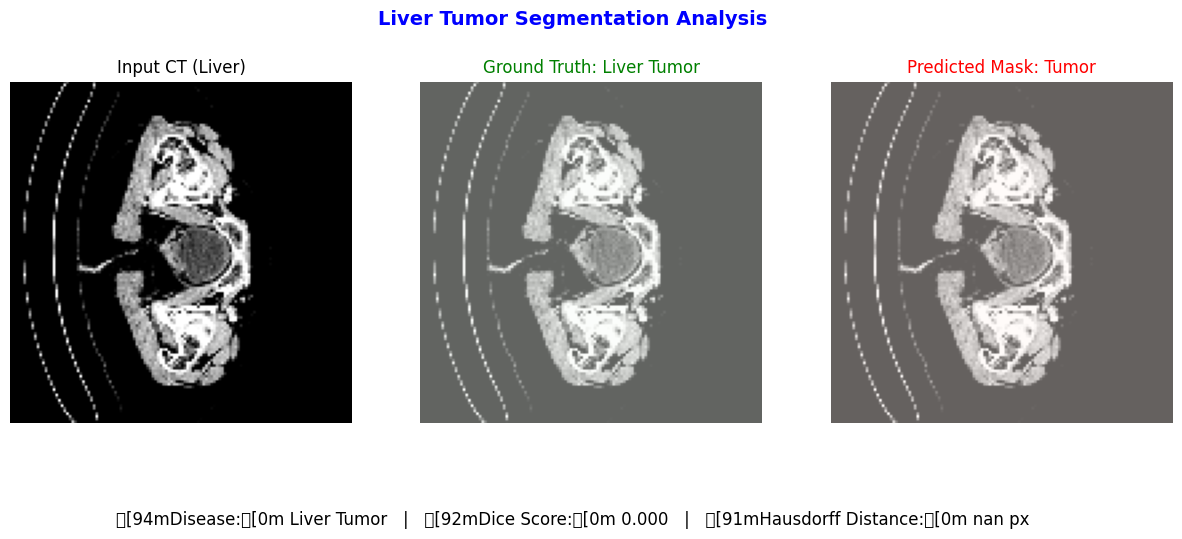

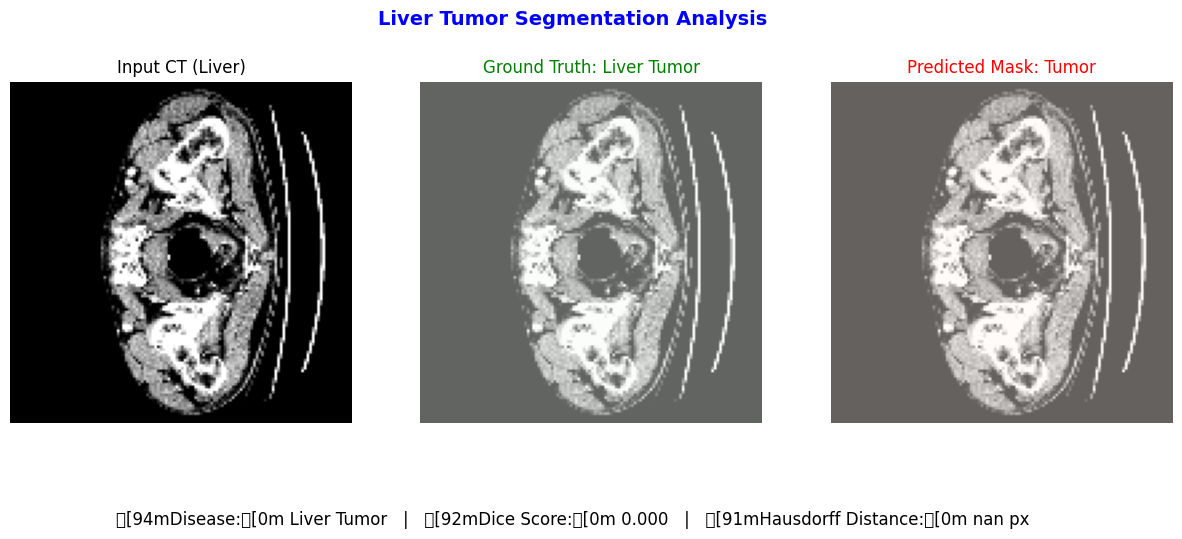

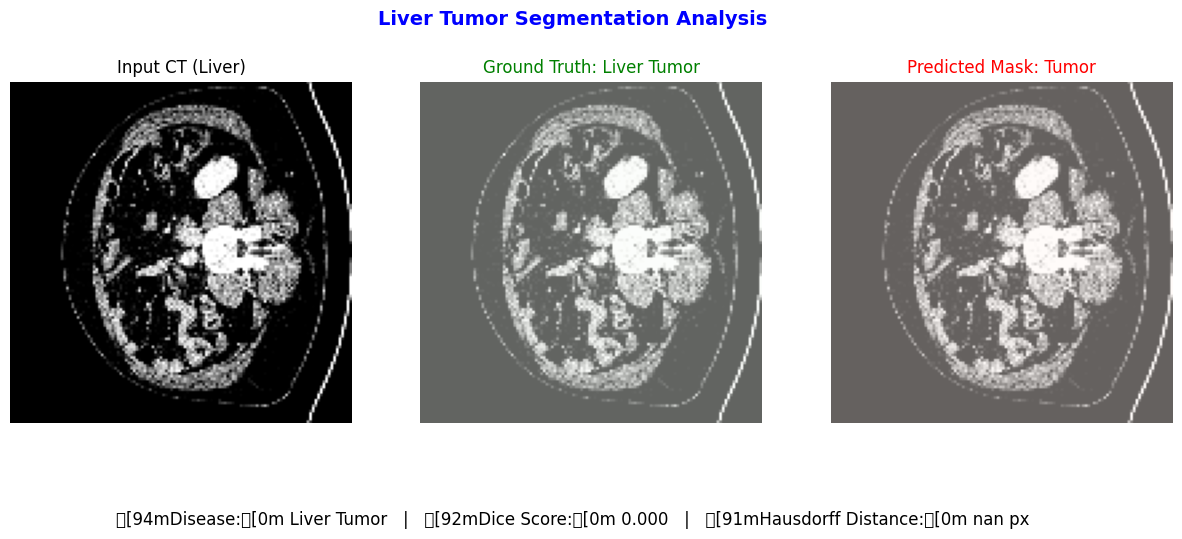

In [9]:

from scipy.spatial.distance import directed_hausdorff

def dice_coefficient(y_true, y_pred):
    y_true_f = y_true.flatten()
    y_pred_f = y_pred.flatten()
    intersection = np.sum(y_true_f * y_pred_f)
    return (2. * intersection) / (np.sum(y_true_f) + np.sum(y_pred_f) + 1e-7)

def hausdorff_distance(y_true, y_pred):
    coords_true = np.argwhere(y_true)
    coords_pred = np.argwhere(y_pred)
    if len(coords_true) == 0 or len(coords_pred) == 0:
        return np.nan
    return max(directed_hausdorff(coords_true, coords_pred)[0],
               directed_hausdorff(coords_pred, coords_true)[0])

def plot_predictions_colorful(model, X, y, num=3):
    preds = model.predict(X[:num])
    
    for i in range(num):
        # Original, GT, Prediction
        img = X[i].squeeze()
        gt_mask = (y[i].squeeze()>0.5).astype(np.uint8)
        pred_mask = (preds[i].squeeze()>0.5).astype(np.uint8)

        # Metrics
        dice = dice_coefficient(gt_mask, pred_mask)
        haus = hausdorff_distance(gt_mask, pred_mask)

        plt.figure(figsize=(15,5))

        # 1. Input CT
        plt.subplot(1,3,1)
        plt.title("Input CT (Liver)", fontsize=12, color="black")
        plt.imshow(img, cmap="gray")
        plt.axis("off")

        # 2. Ground Truth
        plt.subplot(1,3,2)
        plt.title("Ground Truth: Liver Tumor", fontsize=12, color="green")
        plt.imshow(img, cmap="gray")
        plt.imshow(gt_mask, cmap="Greens", alpha=0.4)
        plt.axis("off")

        # 3. Prediction
        plt.subplot(1,3,3)
        plt.title("Predicted Mask: Tumor", fontsize=12, color="red")
        plt.imshow(img, cmap="gray")
        plt.imshow(pred_mask, cmap="Reds", alpha=0.4)
        plt.axis("off")

        # Global Title
        plt.suptitle("Liver Tumor Segmentation Analysis", fontsize=14, weight="bold", color="blue")

        # Colorful Analysis Text
        plt.figtext(0.5, -0.05,
                    f"\033[94mDisease:\033[0m Liver Tumor   |   "
                    f"\033[92mDice Score:\033[0m {dice:.3f}   |   "
                    f"\033[91mHausdorff Distance:\033[0m {haus:.2f} px",
                    wrap=True, ha="center", fontsize=12)

        plt.show()

# Run visualization
plot_predictions_colorful(model, X_val, y_val, num=3)